In [1]:
import h5py

file_path = r"Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys:")
    for key in f.keys():
        print(key)

Keys:
X
Y
Z


In [2]:
with h5py.File(file_path, "r") as f:
    for key in f.keys():
        print(key, f[key].shape)

X (2555904, 1024, 2)
Y (2555904, 24)
Z (2555904, 1)


In [3]:
import h5py
import numpy as np



with h5py.File(file_path, "r") as f:
    X = f["X"]
    Y = f["Y"]
    Z = f["Z"]

    print("X shape:", X.shape)
    print("Y shape:", Y.shape)
    print("Z shape:", Z.shape)

    print("\nFirst Y:")
    print(Y[0])

    print("\nFirst Z:")
    print(Z[0])

    print("\nX[0] shape:")
    print(X[0].shape)

    print("\nFirst 5 IQ samples:")
    print(X[0][:120])

X shape: (2555904, 1024, 2)
Y shape: (2555904, 24)
Z shape: (2555904, 1)

First Y:
[1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First Z:
[-20]

X[0] shape:
(1024, 2)

First 5 IQ samples:
[[ 4.20273952e-02  2.34763235e-01]
 [-2.72882611e-01  4.05134916e-01]
 [-2.67072618e-01  2.27498889e-01]
 [-3.14850867e-01 -1.76458597e-01]
 [ 9.63341236e-01 -1.02571023e+00]
 [ 1.87244624e-01  6.44536376e-01]
 [ 2.60705411e-01 -4.00602192e-01]
 [-1.38889417e-01  3.37220818e-01]
 [ 3.51226389e-01 -3.00818056e-01]
 [ 6.83884501e-01 -1.90601695e+00]
 [ 1.19307786e-01  7.23491237e-02]
 [-1.77766070e-01 -3.49935830e-01]
 [ 4.21254300e-02 -2.73146898e-01]
 [ 1.16819859e+00  1.35799253e+00]
 [ 1.13426137e+00  4.34401125e-01]
 [ 3.39727253e-02 -9.00930226e-01]
 [ 1.82389474e+00 -1.91117674e-01]
 [ 1.11155123e-01  3.19545120e-01]
 [ 8.38508904e-01  3.62890035e-01]
 [ 1.07418180e+00  3.98637831e-01]
 [ 3.25316995e-01 -5.00284135e-01]
 [-7.12064922e-01 -2.04506859e-01]
 [-5.76841295e-01  1.49948746e-01]
 [

In [4]:
f= h5py.File(file_path , "r")

In [5]:
X

<Closed HDF5 dataset>

In [6]:
import h5py

f = h5py.File("Dataset/archive/GOLD_XYZ_OSC.0001_1024.hdf5", "r")
x = f["X"]
print(x[0].shape)

(1024, 2)


In [7]:
y= f["Y"]
z=f["Z"]
labels = np.argmax(y , axis = 1)

In [8]:
print("Class IDs:", np.unique(labels))

Class IDs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


In [9]:
import json
with open(r"Dataset/archive/classes-fixed.json" , "r") as f:
    classes = json.load(f)
print(classes)

['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [10]:
sample = x[319488]
sample.shape

(1024, 2)

In [11]:
sample[:10]

array([[-0.50679684,  0.4923161 ],
       [-0.7730785 ,  0.88742954],
       [ 1.0520872 ,  0.29016516],
       [ 1.0212482 , -0.17397913],
       [ 1.1298447 , -0.23737437],
       [ 1.6448045 , -0.36923006],
       [ 0.93749446,  1.4951981 ],
       [-0.13867494,  0.4566157 ],
       [-0.15407032,  0.10436989],
       [ 0.48751155,  1.4139289 ]], dtype=float32)

In [12]:
label = np.argmax(y[319488])
snr = z[319488][0]

In [13]:
print("Class ID:", label)
print("Modulation:", classes[label])
print("SNR:", snr, "dB")

Class ID: 3
Modulation: BPSK
SNR: -20 dB


In [14]:
for i in [0, 4096, 8192, 106496, 106498]:
    print(i, np.argmax(y[i]), z[i][0])

0 0 -20
4096 0 -18
8192 0 -16
106496 1 -20
106498 1 -20


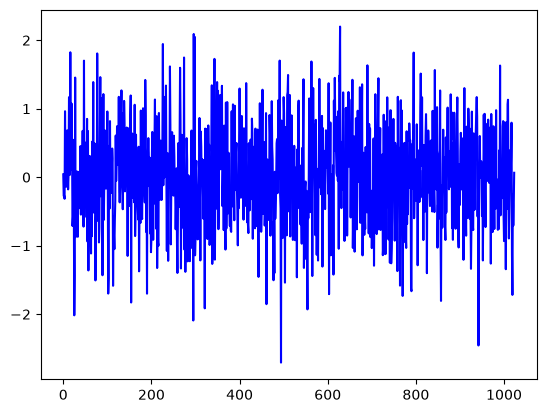

In [28]:
# Now I will plot te see how the signal works
import matplotlib.pyplot as plt
first = x[0]

plt.plot(first[: , 0] , color = "blue" )

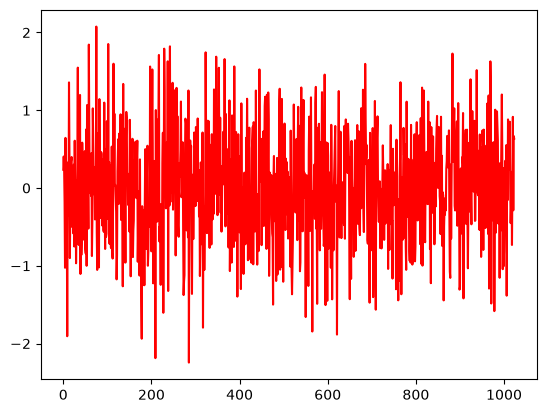

In [16]:
plt.plot( first[: ,1] , color = "red" )

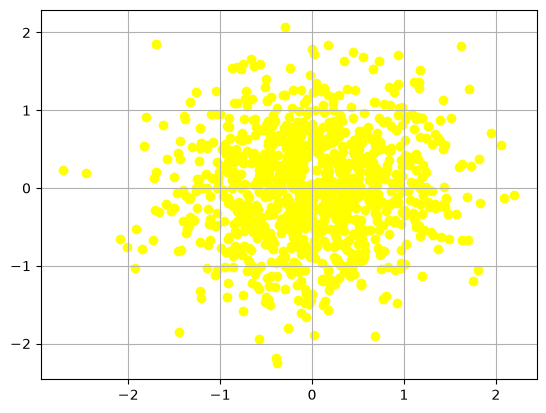

In [27]:
plt.scatter(first[: , 0] , first[: ,1] , color = "yellow" )
plt.grid()

In [18]:
for i in [0,100,189000,10000,969999]:
    label = np.argmax(y[i])
    snr = z[i][0]
    print(f"{i}-->{classes[label]} --> {snr}"
        
    )
    


0-->OOK --> -20
100-->OOK --> -20
189000-->4ASK --> 20
10000-->OOK --> -16
969999-->32APSK --> -16


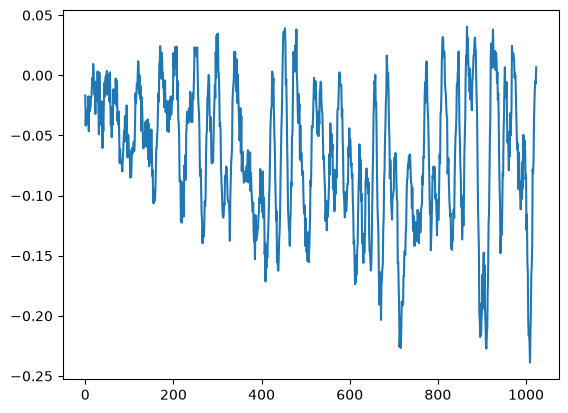

In [19]:
g = 189000
s1 = x[g]
i = s1[: , 0]
q=s1[: ,1]
plt.plot(i)

In [20]:
print(np.unique(z))

[-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


In [21]:
for i in np.unique(z[:,0]):
    count = np.sum(z[:, 0] == i)
    print(f"{i} --> {count}")

-20 --> 98304
-18 --> 98304
-16 --> 98304
-14 --> 98304
-12 --> 98304
-10 --> 98304
-8 --> 98304
-6 --> 98304
-4 --> 98304
-2 --> 98304
0 --> 98304
2 --> 98304
4 --> 98304
6 --> 98304
8 --> 98304
10 --> 98304
12 --> 98304
14 --> 98304
16 --> 98304
18 --> 98304
20 --> 98304
22 --> 98304
24 --> 98304
26 --> 98304
28 --> 98304
30 --> 98304


In [22]:
for g in np.unique(labels):
    count = np.sum(labels == g)
    print(f"{classes[g]}--> {count}")

OOK--> 106496
4ASK--> 106496
8ASK--> 106496
BPSK--> 106496
QPSK--> 106496
8PSK--> 106496
16PSK--> 106496
32PSK--> 106496
16APSK--> 106496
32APSK--> 106496
64APSK--> 106496
128APSK--> 106496
16QAM--> 106496
32QAM--> 106496
64QAM--> 106496
128QAM--> 106496
256QAM--> 106496
AM-SSB-WC--> 106496
AM-SSB-SC--> 106496
AM-DSB-WC--> 106496
AM-DSB-SC--> 106496
FM--> 106496
GMSK--> 106496
OQPSK--> 106496


In [26]:
for i in range (0,500000 , 50000):
    label = np.argmax(y[i])
    print(label)

0
0
0
1
1
2
2
3
3
4
